oracle_gap 1.47457227336803
continuous_gap 3.0929585430117315
binary_gap 3.2307180915275477
pmt 4.445459620135024


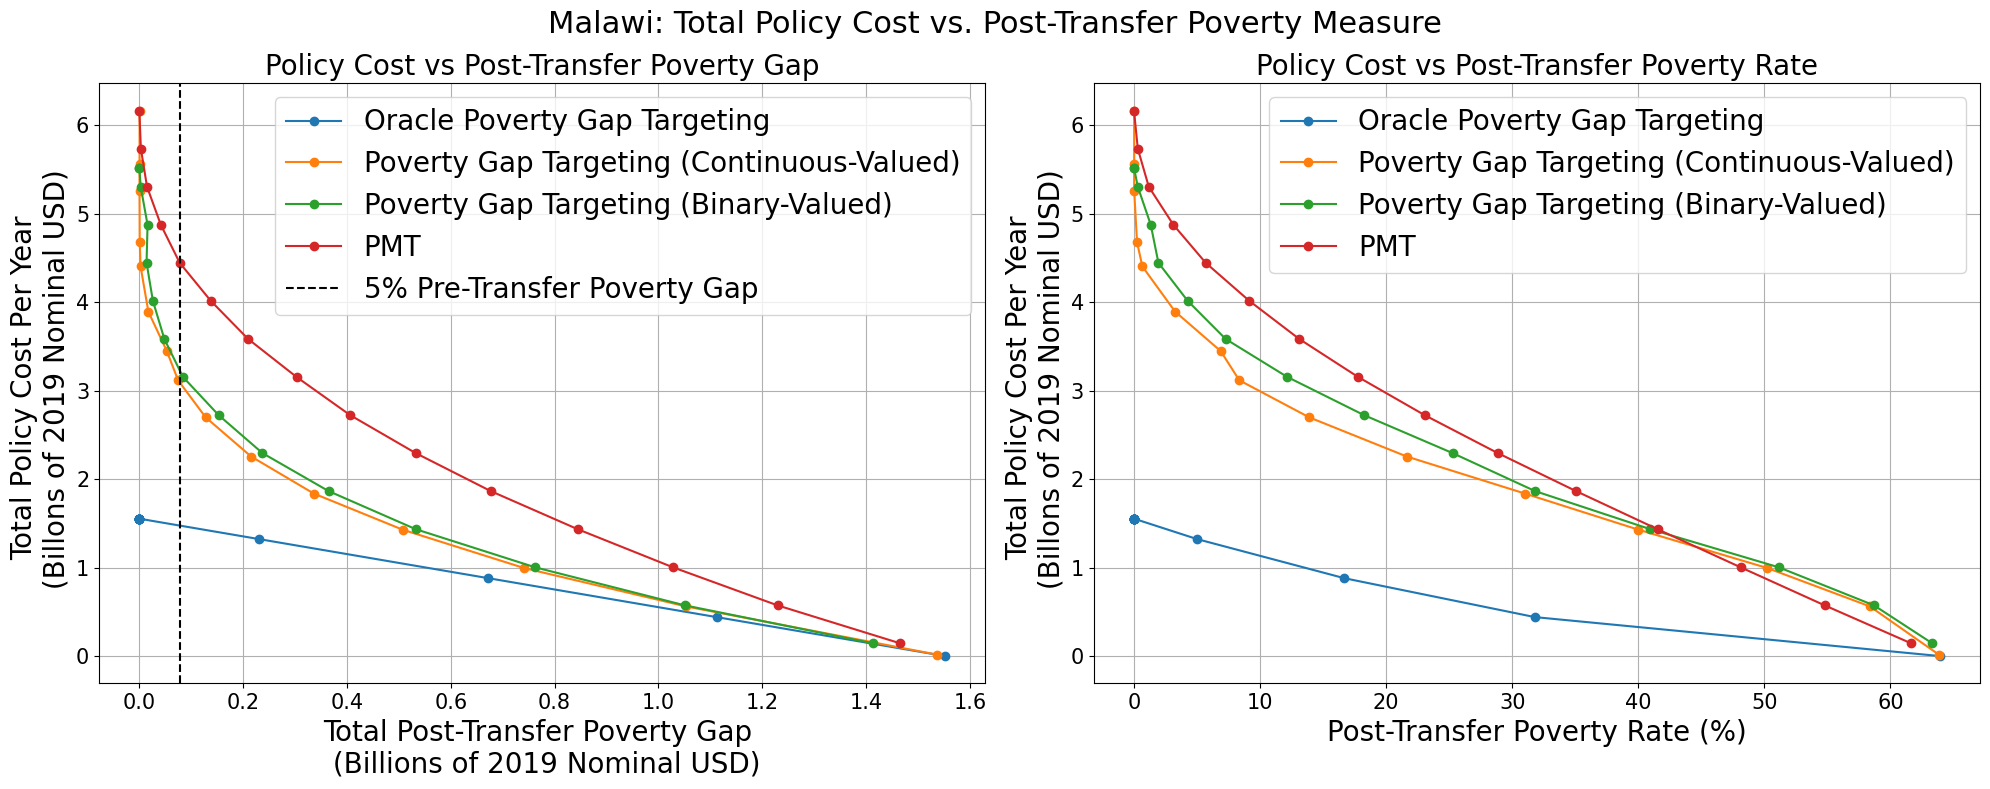

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
# Load data from CSV file
methods = {'oracle_gap': {'csv' : 'oracle_gap', 'name': 'Oracle Poverty Gap Targeting'}, 
           'continuous_gap': {'csv': 'default_continuous_gap','name': 'Poverty Gap Targeting (Continuous-Valued)'},
           'binary_gap': {'csv': 'default_binary_gap', 'name': 'Poverty Gap Targeting (Binary-Valued)'},
           'pmt': {'csv': 'pmt', 'name': 'PMT'},}

conversion_factor = 1.04 * 365 * 22216120 * 0.34 / 1000000000

for method in methods:
    dic = methods[method]
    df = pd.read_csv('results/{}.csv'.format(dic['csv']))
    df['method'] = dic['name']
    dic['df'] = df

fontsize = 20

pre_transfer_poverty_gap = max(methods['oracle_gap']['df']['post_transfer_poverty_gap'])


# Plot policy_cost_per_capita vs post_transfer_poverty_rate
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

for method in methods:
    dic = methods[method]
    df = dic['df']
    ax[1].plot(df['post_transfer_poverty_rate'] * 100, df['policy_cost_per_capita'] * conversion_factor, marker='o', label=dic['name'])
    rate_interpolator = interp1d(df['post_transfer_poverty_rate'] * 100, df['policy_cost_per_capita'] * conversion_factor, kind='linear')
    ax[0].plot(df['post_transfer_poverty_gap'] * conversion_factor, df['policy_cost_per_capita'] * conversion_factor, marker='o', label=dic['name'])
    gap_interpolator = interp1d(df['post_transfer_poverty_gap'] * conversion_factor, df['policy_cost_per_capita'] * conversion_factor, kind='linear')
    #print(method, gap_interpolator(max()))
    print(method, gap_interpolator(pre_transfer_poverty_gap * conversion_factor * 0.05))
ax[1].set_xlabel('Post-Transfer Poverty Rate (%)', fontsize=fontsize)
ax[0].set_xlabel('Total Post-Transfer Poverty Gap \n (Billions of 2019 Nominal USD)', fontsize=fontsize)
    
ax[1].set_title('Policy Cost vs Post-Transfer Poverty Rate', fontsize=fontsize)
ax[0].set_title('Policy Cost vs Post-Transfer Poverty Gap', fontsize=fontsize)

#ax[0].axvline(x=5, color="black", linestyle='--', label='5% Poverty Rate')
ax[0].axvline(x=pre_transfer_poverty_gap * conversion_factor * 0.05, color="black", linestyle='--', label='5% Pre-Transfer Poverty Gap')

for i in range(2):
    ax[i].legend(fontsize=fontsize)
    ax[i].set_ylabel('Total Policy Cost Per Year \n (Billons of 2019 Nominal USD)', fontsize=fontsize)
    ax[i].grid(True)
    ax[i].tick_params(axis='x', labelsize=15)  
    ax[i].tick_params(axis='y', labelsize=15)


plt.suptitle('Malawi: Total Policy Cost vs. Post-Transfer Poverty Measure', fontsize=fontsize + 2)
plt.tight_layout()
plt.savefig("abstract.pdf", bbox_inches='tight')


In [18]:
2.15 * 1.04 * 0.34 * 365 * 22216120 / 1000000000

6.164697820111999